In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [83]:
df = pd.read_csv("IceCreamData.csv")
df.head()

,Temperature,Revenue
0,24.566884,534.799028
1,26.005191,625.190122
2,27.790554,660.632289
3,20.595335,487.706960
4,11.503498,316.240194


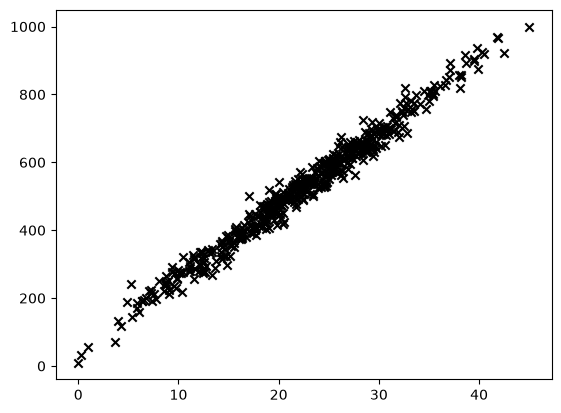

In [84]:
X = df["Temperature"]
y = df["Revenue"]
plt.scatter(X,y, color="black", marker='x')
plt.show()

In [85]:
def loss_function(w, b, points):
    total_error = 0
    for i in range(len(points)):
        x = points.iloc[i]['Temperature']
        y = points.iloc[i].Revenue
        y_pred = w * x + b
        total_error += (y - y_pred) **2
    return total_error / len(points)

print(loss_function(0,0,df))
print(loss_function(2,0,df))
print(loss_function(1,0,df))

302741.3680553478
252986.0200415259
277304.0018267513


In [105]:
a = np.array([1,2,4,5])
b = np.array([1,2,3,4])

np.dot(a,b)

np.int64(37)

In [86]:
def gradient_descent(w_now, b_now, points, learning_rate=0.001):
    de_dw = 0
    de_db = 0

    n = len(points)

    for i in range(n):
        x = points.iloc[i].Temperature
        y = points.iloc[i].Revenue

        y_pred = w_now * x + b_now

        de_dw += -(2/n) * x * (y - y_pred)
        de_db += -(2/n) * (y - y_pred)
    
    w = w_now - learning_rate * de_dw
    b = b_now - learning_rate * de_db

    return w,b


Epoch: 0
Epoch: 50


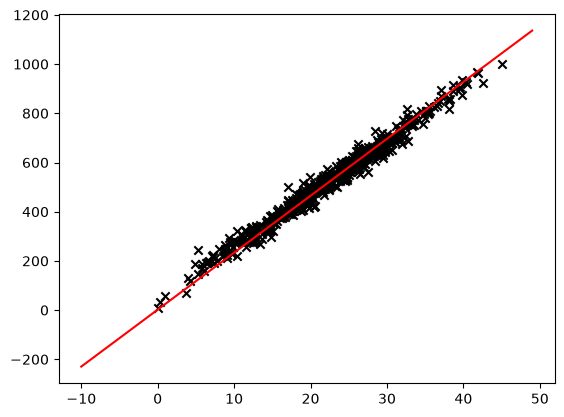

In [110]:
epochs = 100
w =0
b = 0
time_over_error = []

for i in range(epochs):
    w, b = gradient_descent(w, b,df)
    if(True):
        error = loss_function(w, b, df)
        time_over_error.append(error)

    if(i % 50 == 0):
        print(f"Epoch: {i}")

X = df["Temperature"]
y = df["Revenue"]
plt.scatter(X, y, color="black", marker='x')
plt.plot(list(range(-10, 50)), [w * x + b for x in range(-10, 50)], color="red")
plt.show()

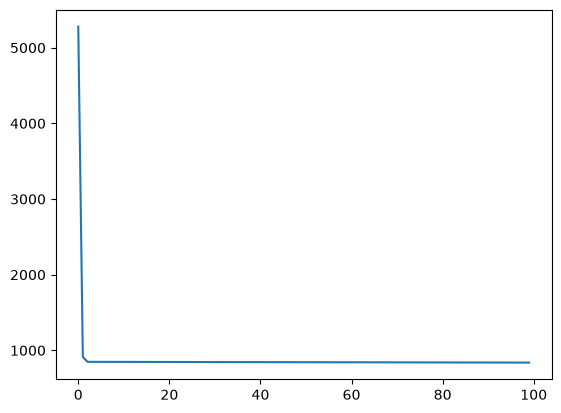

In [88]:
plt.plot(time_over_error)
plt.show()

In [107]:
class LinearRegression:
    def __init__(self, learning_rate=0.001, n_iterations=100):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weight = 0
        self.bias = 0
        self.loss = []

    @staticmethod
    def _mean_squared_error( y, y_hat):
        n = y.shape[0]
        error =  np.sum((y - y_hat) **2) / n

        return error 
    
    def _gradient_descent(self, X, y):
        de_dw = 0
        de_db = 0

        n = y.shape[0]


        y_hat = self.weight * X + self.bias

        de_dw = -(2/n) * np.dot( X , (y - y_hat))
        de_db = -(2/n) * np.sum(y - y_hat)
        
        self.weight -= self.learning_rate * de_dw
        self.bias -= self.learning_rate * de_db

    def fit(self,X,y):
        for _ in range(self.n_iterations):
            self._gradient_descent(X,y)
            y_hat = self.weight * X + self.bias
            loss = self._mean_squared_error(y, y_hat)
            self.loss.append(loss)

    def predict(self,X):
        return self.weight * X + self.bias

In [122]:
X = df['Temperature']
y = df['Revenue']

model = LinearRegression(learning_rate=0.00001)

model.fit(X,y)

print(model.weight, model.bias)

15.678352595367507 0.6331728413204318


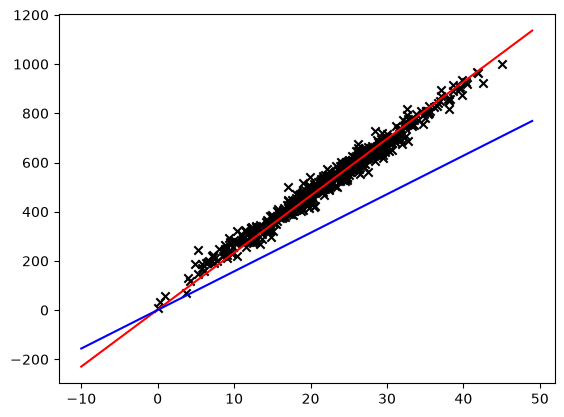

In [124]:
plt.scatter(X, y, color="black", marker='x')
plt.plot(list(range(-10, 50)), [w * x + b for x in range(-10, 50)], color="red")
plt.plot(list(range(-10, 50)), [model.weight * x + model.bias for x in range(-10, 50)], color="blue")
plt.show()

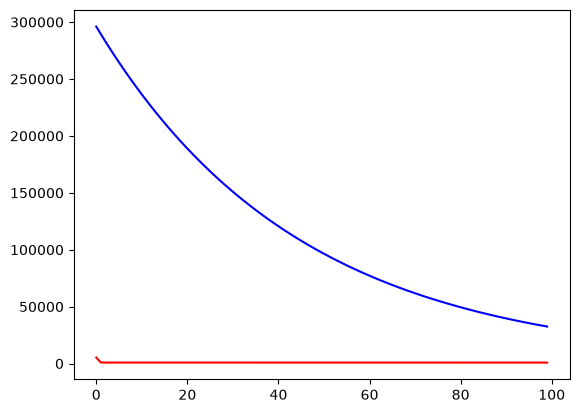

In [125]:
plt.plot(time_over_error, color="red")
plt.plot(model.loss, color="blue")
plt.show()